# Lab 6: Introducing Classification

Objectives:
- To gain hands-on experience classifying small dataset
- To implement concepts related to Decision Tree classifier (i.e. Entropy, Information Gain), along with using existing libraries.

### Code it yourself

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree


In [2]:
# Read the data
df = pd.read_csv("toy_data.csv")
df

,age,income,student,credit rating,buys computer
0,<=30,high,no,fair,no
1,<=30,high,no,excellent,no
2,31-40,high,no,fair,yes
3,>40,medium,no,fair,yes
4,>40,low,yes,fair,yes
5,>40,low,yes,excellent,no
6,31-40,low,yes,excellent,yes
7,<=30,medium,no,fair,no
8,<=30,low,yes,fair,yes
9,>40,medium,yes,fair,yes


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   age            14 non-null     str  
 1   income         14 non-null     str  
 2   student        14 non-null     str  
 3   credit rating  14 non-null     str  
 4   buys computer  14 non-null     str  
dtypes: str(5)
memory usage: 692.0 bytes
None


**TODO:** Write functions to compute Gain and Entropy, as discussed in the lecture.

In [4]:
def entropy(series):
    probs = series.value_counts(normalize=True)
    return float(-(probs * np.log2(probs)).sum())


def information_gain(df, feature, target):
    total_entropy = entropy(df[target])
    weighted_entropy = 0.0

    for _, subset in df.groupby(feature):
        weight = len(subset) / len(df)
        weighted_entropy += weight * entropy(subset[target])

    return float(total_entropy - weighted_entropy)


target_col = "buys computer"
print(f"Entropy({target_col}): {entropy(df[target_col]):.4f}\n")

gains = {col: information_gain(df, col, target_col) for col in df.columns if col != target_col}
for feature, gain in sorted(gains.items(), key=lambda x: x[1], reverse=True):
    print(f"IG({feature}) = {gain:.4f}")

best_feature = max(gains, key=gains.get)
print(f"\nBest split feature: {best_feature}")


Entropy(buys computer): 0.9403

IG(age) = 0.2467
IG(student) = 0.1518
IG(credit rating) = 0.0481
IG(income) = 0.0292

Best split feature: age


___

### Using Libraries

Now that you know how to compute these values by yourselfs, now let's use some libraries.

**Steps:**
- Split the Data → Divide dataset into training (80%) and testing (20%).
- Train the Model → Fit a Decision Tree using the training data.
- Test the Model → Use the trained model to predict on test data.
- Evaluate Performance → Compare predictions with actual values (e.g., Accuracy Score).

Prepare features and labels.

In [5]:
# Features
features = df.drop("buys computer", axis=1)
features

# Alternatively, you can use this:
# features = df.iloc[:, :-1]

,age,income,student,credit rating
0,<=30,high,no,fair
1,<=30,high,no,excellent
2,31-40,high,no,fair
3,>40,medium,no,fair
4,>40,low,yes,fair
5,>40,low,yes,excellent
6,31-40,low,yes,excellent
7,<=30,medium,no,fair
8,<=30,low,yes,fair
9,>40,medium,yes,fair


In [6]:
# 1. Load the dataset
X = features.values  # Features
y = df["buys computer"].values  # Target labels

# 2. Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Try training with raw categorical values (this will fail and we show the error)
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
try:
    clf.fit(X_train, y_train)
except ValueError as e:
    print(f"Expected error: {e}")


Expected error: could not convert string to float: '31-40'


In [7]:
# Labels (or Target)
labels = df["buys computer"]
labels

# Alternatively, you can use this:
# labels = df.iloc[:, -1]


0      no
1      no
2     yes
3     yes
4     yes
5      no
6     yes
7      no
8     yes
9     yes
10    yes
11    yes
12    yes
13     no
Name: buys computer, dtype: str

There's an error:

**ValueError: could not convert string to float: '31-40'**

In [8]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding for all categorical columns
df["age"] = label_encoder.fit_transform(df["age"])
df["income"] = label_encoder.fit_transform(df["income"])
df["student"] = label_encoder.fit_transform(df["student"])
df["credit rating"] = label_encoder.fit_transform(df["credit rating"])
df["buys computer"] = label_encoder.fit_transform(df["buys computer"])

# Display the encoded DataFrame
print(df)

    age  income  student  credit rating  buys computer
0     1       0        0              1              0
1     1       0        0              0              0
2     0       0        0              1              1
3     2       2        0              1              1
4     2       1        1              1              1
5     2       1        1              0              0
6     0       1        1              0              1
7     1       2        0              1              0
8     1       1        1              1              1
9     2       2        1              1              1
10    1       2        1              0              1
11    0       2        0              0              1
12    0       0        1              1              1
13    2       2        0              0              0


Let's check out an updated dataframe.

In [9]:
df

,age,income,student,credit rating,buys computer
0,1,0,0,1,0
1,1,0,0,0,0
2,0,0,0,1,1
3,2,2,0,1,1
4,2,1,1,1,1
5,2,1,1,0,0
6,0,1,1,0,1
7,1,2,0,1,0
8,1,1,1,1,1
9,2,2,1,1,1


In [10]:
X = df.drop("buys computer", axis=1)  # Features
y = df["buys computer"]  # Target

Let's continue where we left off!

In [11]:
# 2. Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create and train a Decision Tree model with entropy criterion
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [12]:
print(X_train.shape)
print(X_test.shape)

(11, 4)
(3, 4)


Now we're going build the Decision Tree Classifier

In [13]:
# Initialize the Decision Tree classifier
clf = DecisionTreeClassifier(
    criterion="entropy", random_state=42
)  # Using 'entropy' as the criterion

# Train the model
clf.fit(X_train, y_train)

# Predict on the test set
y_pred = clf.predict(X_test)


And evaluate our model.

In [14]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion Matrix:
[[1 0]
 [0 2]]


And visualize our tree!

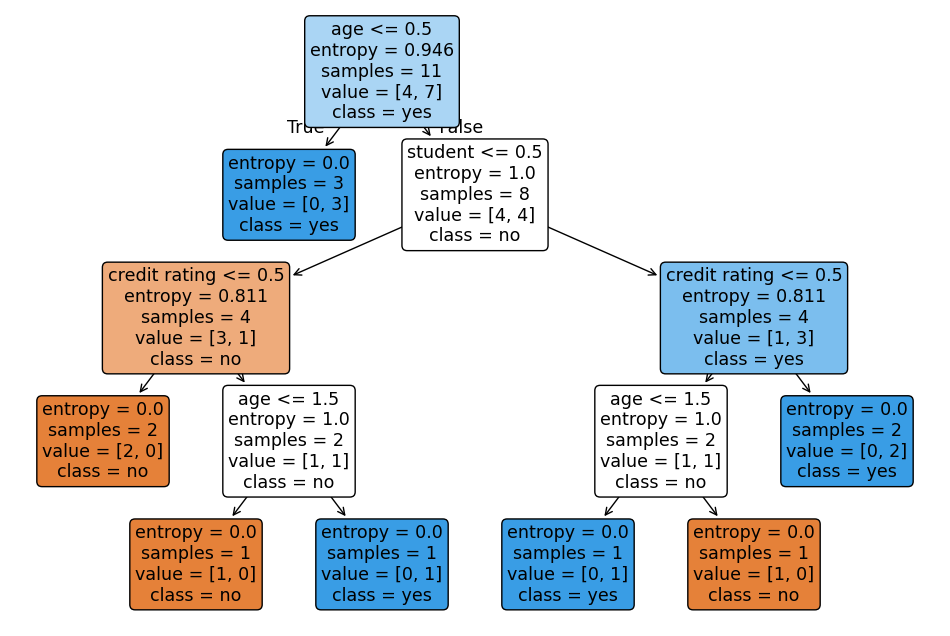

In [15]:
# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=["no", "yes"], rounded=True)
plt.show()

Put them all together.

Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3

Confusion Matrix:
[[1 0]
 [0 2]]


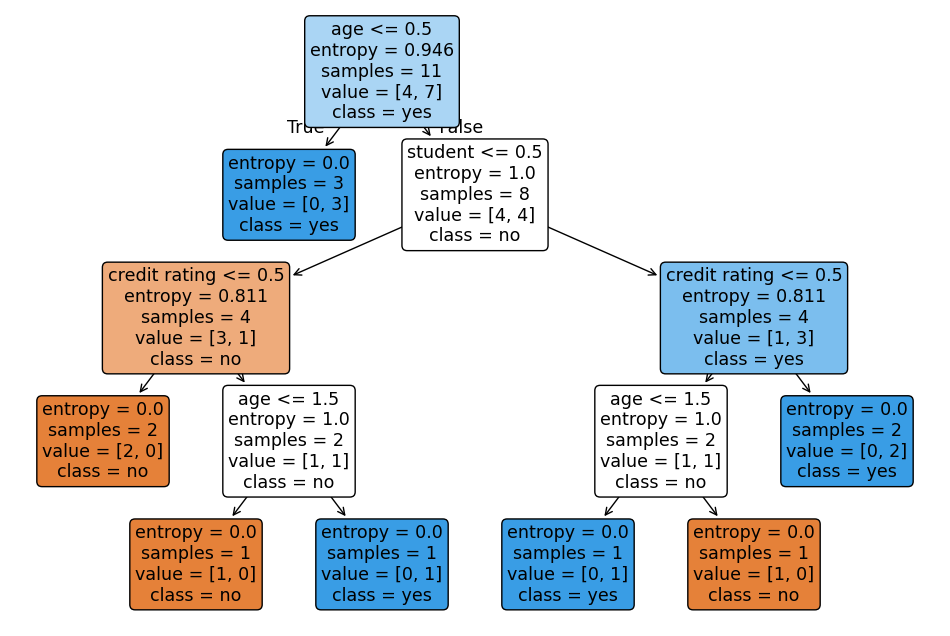

In [16]:
# data
data = pd.read_csv("toy_data.csv")

df = pd.DataFrame(data)

# Encode categorical columns using LabelEncoder
label_encoder = LabelEncoder()
df["age"] = label_encoder.fit_transform(df["age"])
df["income"] = label_encoder.fit_transform(df["income"])
df["student"] = label_encoder.fit_transform(df["student"])
df["credit rating"] = label_encoder.fit_transform(df["credit rating"])
df["buys computer"] = label_encoder.fit_transform(df["buys computer"])

# Separate features (X) and target (y)
X = df.drop("buys computer", axis=1)
y = df["buys computer"]

# Split the dataset into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree classifier
clf = DecisionTreeClassifier(criterion="entropy", random_state=42)

# Train the model
clf.fit(X_train, y_train)

# Predict on the test set
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=["no", "yes"], rounded=True)
plt.show()


Is the output tree the same as what you calculated yourself? Explain in your own words why they are the same or different.\n
\n
**Ans:** It should be very similar at the top split because both methods use entropy/information gain (ID3-style logic). Minor differences can still appear due to implementation details such as how categorical values are encoded, tie-breaking when gains are equal/close, and constraints like depth limits or stopping rules in scikit-learn.\n

___

Another example, another dataset -- Iris

Model Accuracy: 1.00


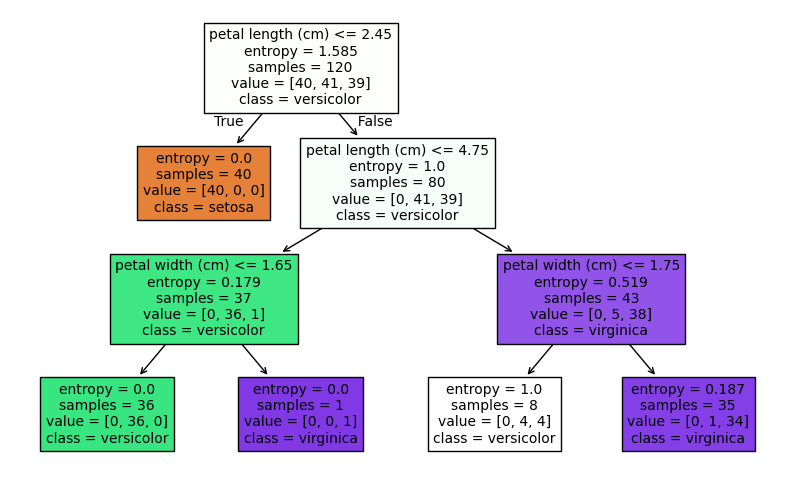

In [17]:
# 1. Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target  # Target labels

# 2. Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create and train a Decision Tree model with entropy criterion
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = clf.predict(X_test)

# 5. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# 6. Visualize the Decision Tree
plt.figure(figsize=(10, 6))
plot_tree(clf, filled=True, feature_names=iris.feature_names, class_names=iris.target_names)
plt.show()
